In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from timm import create_model
from pathlib import Path
from model.image_dataset import ImageDataset
from model.classification import ClassificationType
from tqdm import tqdm
import timm
import numpy as np

# config

In [6]:
BATCH_SIZE = 64
EPOCHS = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, "data", "processed")

cuda:0


# Split 2

In [7]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.4104351758956909, 0.4893591821193695, 0.4897149622440338]
train_transform  = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
val_path = Path(os.path.join(data_dir, "val"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, train_transform)
val_dataset = ImageDataset(val_path, eval_transform)
test_dataset = ImageDataset(test_path, eval_transform)

from torch.utils.data import Subset
# train_dataset = Subset(ImageDataset(train_path, transform), range(50000))
# val_dataset = Subset(ImageDataset(val_path, transform), range(1000))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# load model

In [8]:
num_classes = ClassificationType.get_number_of_types()

# Tworzenie nieprzetrenowanego modelu ResNet
model = timm.create_model('resnet50', pretrained=False)

# Zamiana ostatniej warstwy klasyfikacyjnej
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Reszta bez zmian
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL1.pth"

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

Evaluation: 100%|██████████| 386/386 [00:26<00:00, 14.39it/s]


Epoch 1/10, Train Loss: 0.2469, Val Loss: 0.1558


Evaluation: 100%|██████████| 386/386 [00:26<00:00, 14.33it/s]


Epoch 2/10, Train Loss: 0.1586, Val Loss: 0.1345


Evaluation: 100%|██████████| 386/386 [00:26<00:00, 14.41it/s]


...

Epoch 8/10, Train Loss: 0.1005, Val Loss: 0.0889


Evaluation: 100%|██████████| 386/386 [00:28<00:00, 13.47it/s]


Epoch 9/10, Train Loss: 0.0959, Val Loss: 0.1047


Evaluation: 100%|██████████| 386/386 [00:28<00:00, 13.48it/s]


Epoch 10/10, Train Loss: 0.0924, Val Loss: 0.0857


# plot

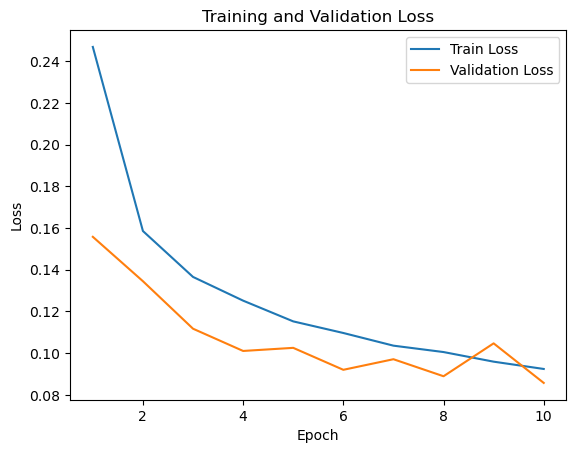

In [9]:
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


In [11]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:32<00:00, 10.75it/s]



✅ Test Accuracy: 97.04%


# Split 1

In [4]:
transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
])
train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = ClassificationType.get_number_of_types()

model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL2.pth"

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

Epoch 1/10:  77%|███████▋  | 2109/2745 [03:41<01:06,  9.54it/s]C:\Users\kubas\anaconda3\envs\deeplearning\Lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluation: 100%|██████████| 386/386 [00:33<00:00, 11.44it/s]


Epoch 1/10, Train Loss: 0.2056, Val Loss: 0.1389


Evaluation: 100%|██████████| 386/386 [00:26<00:00, 14.78it/s]


Epoch 2/10, Train Loss: 0.1290, Val Loss: 0.1155


Evaluation: 100%|██████████| 386/386 [00:26<00:00, 14.31it/s]


...

Epoch 8/10, Train Loss: 0.0583, Val Loss: 0.0973


Evaluation: 100%|██████████| 386/386 [00:43<00:00,  8.94it/s]


Epoch 9/10, Train Loss: 0.0505, Val Loss: 0.1059


Evaluation: 100%|██████████| 386/386 [00:43<00:00,  8.91it/s]

Epoch 10/10, Train Loss: 0.0444, Val Loss: 0.1026


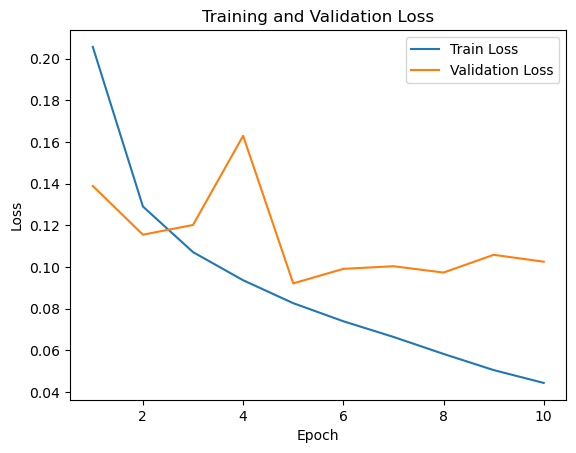

In [6]:
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


In [5]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:36<00:00,  9.45it/s]


✅ Test Accuracy: 96.86%


# Split 3

In [9]:
from torch.utils.data import Subset
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.5104351758956909, 0.5893591821193695, 0.5897149622440338]
train_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, train_transform)
test_dataset = ImageDataset(test_path, eval_transform)

val_size = int(0.2 * len(train_dataset))
train_indices = np.arange(len(train_dataset))
val_indices = np.random.choice(train_indices, size=val_size, replace=False)
val_dataset = Subset(train_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


num_classes = ClassificationType.get_number_of_types()

model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL3.pth"

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

Evaluation: 100%|██████████| 549/549 [01:22<00:00,  6.64it/s]


Epoch 1/10, Train Loss: 0.2514, Val Loss: 0.1668


Evaluation: 100%|██████████| 549/549 [01:09<00:00,  7.92it/s]


Epoch 2/10, Train Loss: 0.1599, Val Loss: 0.1792


Evaluation: 100%|██████████| 549/549 [00:41<00:00, 13.17it/s]


...

Epoch 8/10, Train Loss: 0.0997, Val Loss: 0.0939


Evaluation: 100%|██████████| 549/549 [00:41<00:00, 13.10it/s]


Epoch 9/10, Train Loss: 0.0950, Val Loss: 0.0979


Evaluation: 100%|██████████| 549/549 [00:41<00:00, 13.16it/s]

Epoch 10/10, Train Loss: 0.0926, Val Loss: 0.0855


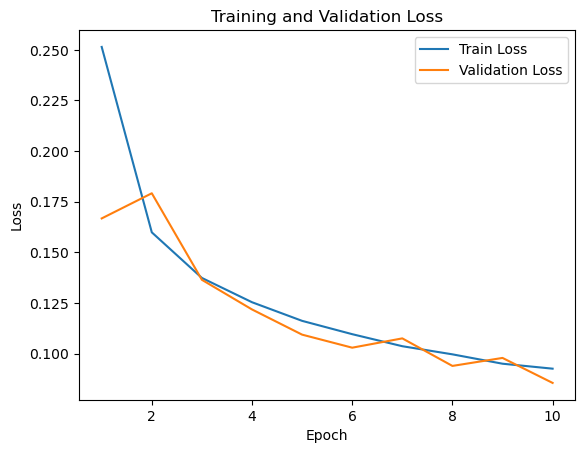

In [10]:
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [11]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:25<00:00, 13.70it/s]


✅ Test Accuracy: 97.14%


# Overfit model

In [17]:
from torch.utils.data import Subset
transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
])
train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = Subset(ImageDataset(train_path, transform), list(range(10000)))
test_dataset = ImageDataset(test_path, transform)
val_dataset = Subset(ImageDataset(val_path, transform), list(range(2000)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = ClassificationType.get_number_of_types()

model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

train_losses = []
val_losses = []
best_val_loss = float('inf')
# best_model_path = "overfit.pth"
overfit_epochs = 30

for epoch in range(overfit_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{overfit_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # torch.save(model.state_dict(), best_model_path)

Evaluation: 100%|██████████| 32/32 [00:01<00:00, 16.04it/s]


Epoch 1/30, Train Loss: 0.8639, Val Loss: 0.1888


Evaluation: 100%|██████████| 32/32 [00:01<00:00, 16.60it/s]


Epoch 2/30, Train Loss: 0.0378, Val Loss: 0.0189


Evaluation: 100%|██████████| 32/32 [00:01<00:00, 16.63it/s]


...

Epoch 28/30, Train Loss: 0.0238, Val Loss: 0.0230


Evaluation: 100%|██████████| 32/32 [00:02<00:00, 10.98it/s]


Epoch 29/30, Train Loss: 0.0074, Val Loss: 0.0233


Evaluation: 100%|██████████| 32/32 [00:01<00:00, 16.90it/s]


Epoch 30/30, Train Loss: 0.0070, Val Loss: 0.0256


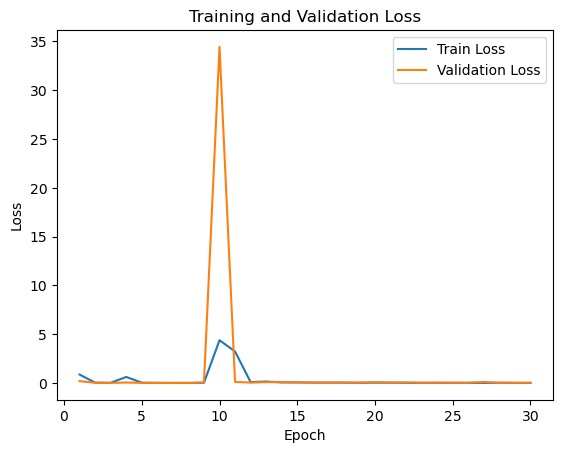

In [18]:
plt.plot(range(1, 30 + 1), train_losses, label="Train Loss")
plt.plot(range(1, 30 + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [19]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:23<00:00, 14.87it/s]


✅ Test Accuracy: 40.27%
